Setup:

In [876]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3-8B')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Meta-Llama-3-8B', dtype=torch.bfloat16)

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 8398.36it/s]


In [877]:
from transformers import TextStreamer

def test_perplexity_and_response(model, tokenizer):
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    text = 'The quick brown fox jumps over the lazy dog.'
    inputs = tokenizer(text, return_tensors='pt', padding=True).to(model.device)

    with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
        outputs = model(**inputs, labels=inputs['input_ids'])
        loss = outputs.loss
        perplexity = torch.exp(loss.float()).item()

    print(f'Loss: {loss.item():.4f}')
    print(f'Perplexity: {perplexity:.4f}\n')

    print('Model Response: ', end='')
    streamer = TextStreamer(tokenizer, skip_prompt=True)
    model.generate(
        **inputs, 
        streamer=streamer, 
        max_new_tokens=20,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.7
    )

In [878]:
length = 0
for name, param in model.named_parameters():
    if 'proj' in name or 'lm_head' in name:
        print(name, param.shape)
        length += 1
print(f'Matrix count: {length}')

model.layers.0.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.0.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.0.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.1.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.1.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.1.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.2.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.2.self_attn.k_proj.weight torch.Size([1024,

In [879]:
q_proj_weight = model.model.layers[8].self_attn.q_proj.weight
print(q_proj_weight.shape)   # torch.Size([4096, 4096])
print(q_proj_weight)

k_proj_weight = model.model.layers[5].self_attn.k_proj.weight
print(k_proj_weight.shape)   # torch.Size([4096, 4096])
print(k_proj_weight)

torch.Size([4096, 4096])
Parameter containing:
tensor([[-0.0074, -0.0166,  0.0028,  ...,  0.0008, -0.0066,  0.0116],
        [ 0.0112, -0.0211,  0.0008,  ...,  0.0194, -0.0116, -0.0056],
        [ 0.0009, -0.0139, -0.0002,  ...,  0.0126, -0.0183, -0.0157],
        ...,
        [-0.0146,  0.0150, -0.0327,  ...,  0.0127,  0.0153, -0.0077],
        [-0.0278,  0.0090,  0.0352,  ...,  0.0417, -0.0126,  0.0063],
        [-0.0417, -0.0125,  0.0002,  ..., -0.0264,  0.0198,  0.0111]],
       dtype=torch.bfloat16, requires_grad=True)
torch.Size([1024, 4096])
Parameter containing:
tensor([[-0.0021,  0.0483, -0.0437,  ...,  0.0026, -0.0344,  0.0060],
        [ 0.0170,  0.0552,  0.0059,  ...,  0.0112,  0.0259,  0.0011],
        [-0.0035,  0.0186, -0.0403,  ...,  0.0056, -0.0273,  0.0025],
        ...,
        [ 0.0164, -0.0613,  0.0312,  ...,  0.0625,  0.0381, -0.0449],
        [ 0.0226, -0.0013,  0.0204,  ..., -0.0031, -0.0077,  0.0295],
        [ 0.0547, -0.0003, -0.0090,  ...,  0.0167, -0.0089, 

In [880]:
from typing import Literal
import math
import time

from einops import rearrange
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

torch.cuda.empty_cache()
torch.cuda.synchronize()


In [881]:
from matplotlib.colors import ListedColormap

def plot_masks(mask_a, mask_b, mask_type):
    cmap = ListedColormap(['gray', 'lime'])
    _, axs = plt.subplots(1, 2, figsize=(8, 4))

    for ax, mask, title in zip(
        axs,
        [mask_a[:16, :16], mask_b[:16, :16]],
        ['mask_a', 'mask_b']
    ):
        _ = ax.imshow(mask, cmap=cmap, vmin=0, vmax=1)

        ax.set_xticks(np.arange(-0.525, 16, 1), minor=True,)
        ax.set_yticks(np.arange(-0.55, 16, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

        if mask_type == '2to4':
            for x in np.arange(-0.5, 16, 4):
                ax.axvline(x=x, color='deepskyblue', linewidth=1.5)
            for y in np.arange(-0.5, 16, 1):
                ax.axhline(y=y, color='deepskyblue', linewidth=1.5)

        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [882]:
q_proj_weight = q_proj_weight.cuda()
print(q_proj_weight.device)
print(q_proj_weight.dtype)

k_proj_weight = k_proj_weight.cuda()
print(k_proj_weight.device)
print(k_proj_weight.dtype)

cuda:0
torch.bfloat16
cuda:0
torch.bfloat16


Mask functions:

In [883]:
def mag_prune(W, sp=0.5):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return W * mask

In [884]:
def _mag_prune_mask(W, sp=0.6):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return mask

In [885]:
def _block_mask(
    W_hat: torch.Tensor,
    U: torch.Tensor,
    bsparsity: float,
    rows: int, cols: int
) -> torch.Tensor:
    h, w = W_hat.shape

    blocks = (W_hat + U).reshape(h // rows, rows, w // cols, cols)
    block_norms_sq = blocks \
                        .pow(2) \
                        .sum(dim=(1, 3))  # sqrt skipped as it has no effect

    # pick top blocks
    flat = block_norms_sq.flatten()
    k = max(1, int(bsparsity * flat.numel()))
    thres = torch.kthvalue(flat, k).values

    # expand back
    block_mask = block_norms_sq > thres
    return block_mask.repeat_interleave(rows, dim=0).repeat_interleave(cols, dim=1)


In [886]:
def default_block_mask(W_hat, U, bsparsity):
    return _block_mask(W_hat, U, bsparsity, 2, 2)

In [887]:
def _get_mask_2_to_4(
    W_hat: torch.Tensor, 
    U: torch.Tensor,
    bsparsity: float,
    transpose: bool = True
) -> torch.Tensor:

    W_U_sum = W_hat + U
    if transpose:
        W_U_sum = W_U_sum.T
    rows = W_U_sum.shape[0]
    thres = int(W_U_sum.numel() * (1 - bsparsity)) # 16% or 24% of elements

    # create groups of 4 and sort the 4 elements in each one
    W_U_sum_grouped = W_U_sum.reshape(rows, -1, 4)
    g_sorted_elements, _ = W_U_sum_grouped.abs().sort(dim=-1, descending=True)
    
    # calculate norms of [top two elements] in each group
    # then sort groups according to the result
    # (we use norm as that performed best in usual block sparsity)
    top2_sums = g_sorted_elements[:, :, :2].norm(dim=-1, p=2)
    _, best_group_ids = top2_sums.flatten().sort(descending=True)
    
    group_take_count = (thres // 4) * 2
    # each group contains 4 elements, so we divide by 4, but 2:4 will be applied,
    # so we multiply by 2 to get the desired sparsity

    # group-wise mask
    # we get locations of groups where the calculated norms are the highest
    # we keep these locations in the mask
    all_groups_count = W_U_sum_grouped.shape[1]
    g_mask = torch.zeros(rows * all_groups_count, dtype=torch.bool, device=W_U_sum.device)
    g_mask[best_group_ids[:group_take_count]] = True
    g_mask = g_mask.reshape(rows, all_groups_count)

    # apply 2:4 in selected groups -> now we get back to 16%/24% sparsity
    # we select top two elements in absolute value as they contribute the most to the norm
    _, ids = W_U_sum_grouped.abs().topk(2, dim=-1, sorted=False)
    mask = torch.zeros_like(W_U_sum_grouped, dtype=torch.bool)
    mask = mask.scatter(-1, ids, True)
    mask = mask & g_mask.unsqueeze(-1) # add dim to zero out the remaining groups
    mask = mask.reshape(rows, -1)
    
    del W_U_sum_grouped, g_sorted_elements, top2_sums, g_mask
    if transpose:
        mask = mask.T
    return mask

Factorization functions:

In [888]:
# penalty factor
RHO = 0.5

In [889]:
# inner loop of the ||W-AB||_2 minization algorithm
# ADMM is performed for m (iters) iterations
def find_other2(X, W, nnz, Z, U, mask_type, alt=False, reg=0, rho_start=0.03, iters=5, prune_iters=2):
    # Z_0 = identity
    # U_0 = zero matrix
    # X can be:
    # -> A, when we're solving for B (Z) and U_b (U)
    # -> B, when we're solving for A (Z) and U_a (U)
    X, W, Z, U = X.float(), W.float(), Z.float(), U.float()

    # normalization with diag. reg.
    norm2 = torch.linalg.vector_norm(X, dim=0) + 1e-8
    An = X / norm2
    XTX = An.T.matmul(An)
    
    mean_diag = XTX.trace() / XTX.shape[0]
    if reg > 0:
        XTX.diagonal().add_(mean_diag * reg)
    
    rho = RHO
    XTW = An.T.matmul(W)

    # XTX_inv = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho)
    # XTX_inv2 = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho_start)
    XTX.diagonal().add_(rho_start)
    L2 = torch.linalg.cholesky(XTX)

    XTX.diagonal().add_(rho - rho_start)
    L = torch.linalg.cholesky(XTX)
    ########################

    U = U * norm2.unsqueeze(1)
    Z = Z * norm2.unsqueeze(1)
    
    # W_hat = XTX_inv2.matmul(XTW + rho_start*(Z-U))
    RHS_start = XTW + rho_start * (Z - U)
    W_hat = torch.cholesky_solve(RHS_start, L2)
    ########################

    bsparsity = min(0.99, 1 - nnz/W_hat.numel()) # 0.76 or 0.84

    for itt in range(iters):            
        if itt < prune_iters:
            if not mask_type:
                mask = _mag_prune_mask(W_hat+U, bsparsity)
            if mask_type == 'blocks':
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=2)

            # if mask_type == 'blocks_alt' and not alt:
            #     mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=1)
            # if mask_type == 'blocks_alt' and alt:
            #     mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=1, cols=2)
            if mask_type == 'blocks_alt':
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=1, cols=2)

            if mask_type == '2to4' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=True)
            if mask_type == '2to4' and alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=False)

            if mask_type == 'hybrid' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity)
            if mask_type == 'hybrid' and alt:
                mask = _mag_prune_mask(W_hat+U, bsparsity)

        # ADMM iterations
        Z = mask * (W_hat + U)
        U = U + (W_hat - Z)

        # W_hat = XTX_inv.matmul(XTW + rho*(Z-U))
        RHS = XTW + rho * (Z - U)
        W_hat = torch.cholesky_solve(RHS, L)
        ########################

    return (Z) / norm2.unsqueeze(1), U / norm2.unsqueeze(1), mask

In [890]:
import torch
from typing import Literal

# ==========================================
# 1. TETRIS Algorithm Implementation
# ==========================================
def apply_tetris_reordering(A: torch.Tensor, B: torch.Tensor, prune_fn, epsilon: float = 1e-5, max_outer_iters: int = 10, max_inner_iters: int = 100):
    """
    Implements the TETRIS reordering algorithm to cluster non-zeros.
    """
    device = A.device
    k = A.shape[1]
    
    if k != B.shape[0]:
        raise ValueError("Inner dimensions of A and B must match.")
        
    # Construct composite matrix W_cat representing the inner dimension 'k'.
    # A.T is [k, n] and B is [k, m]. Concatenating them gives [k, n + m].
    W_cat = torch.cat([A.T, B], dim=1)
    
    # Track the unit permutation
    perm = torch.arange(k, device=device)
    
    for _ in range(max_outer_iters):
        # M-Step: Get importance mask M = P(W)
        M = prune_fn(W_cat).to(W_cat.dtype)
        swaps_made = 0
        
        for _ in range(max_inner_iters):
            # Compute tensor contraction S = |W|M^T 
            S = torch.matmul(torch.abs(W_cat), M.T) 
            L = torch.diag(S) 
            
            # G_ij = S_ii + S_jj - S_ij - S_ji
            G = L.unsqueeze(1) + L.unsqueeze(0) - S - S.T
            # Mask the diagonal to prevent self-swapping
            G.fill_diagonal_(-float('inf'))
            
            # Find the index pair (i, j) that maximizes G
            max_G_idx = torch.argmax(G)
            i = max_G_idx // k
            j = max_G_idx % k
            max_g_val = G[i, j].item()
            
            # Convergence check for the inner loop
            if max_g_val <= epsilon:
                break
                
            # Greedily swap the i-th and j-th slices in W_cat
            w_i = W_cat[i].clone()
            W_cat[i] = W_cat[j]
            W_cat[j] = w_i
            
            # Swap indices in the permutation tracker
            p_i = perm[i].clone()
            perm[i] = perm[j]
            perm[j] = p_i
            
            swaps_made += 1
            
        # Outer loop convergence check
        if swaps_made == 0:
            break
            
    # Apply the final discovered permutation back to A and B
    A_perm = A[:, perm]
    B_perm = B[perm, :]
    
    return A_perm, B_perm, perm

# ==========================================
# 2. Prune Function Wrapper for TETRIS
# ==========================================
def get_tetris_prune_wrapper(mask_type, bsp_A, bsp_B, cols_A, cols_B, alt=False):
    """
    Wraps your existing mask functions to work on the concatenated W_cat tensor.
    Assumes `_mag_prune_mask`, `_block_mask`, and `_get_mask_2_to_4` are globally accessible.
    """
    def prune_fn(W_cat):
        # Split W_cat back into A.T and B
        A_T_hat = W_cat[:, :cols_A]
        B_hat = W_cat[:, cols_A:]
        
        # U is effectively zero during the TETRIS M-Step
        U_A_T = torch.zeros_like(A_T_hat)
        U_B = torch.zeros_like(B_hat)
        
        # Helper to route to your specific masking logic
        def get_mask(W_h, U_h, bsp, is_alt):
            # Default to magnitude if None
            if not mask_type:
                return _mag_prune_mask(W_h + U_h, bsp)
            if mask_type == 'blocks':
                return _block_mask(W_hat=W_h, U=U_h, bsparsity=bsp, rows=2, cols=2)
            if mask_type == 'blocks_alt':
                return _block_mask(W_hat=W_h, U=U_h, bsparsity=bsp, rows=1, cols=2)
            if mask_type == '2to4':
                return _get_mask_2_to_4(W_hat=W_h, U=U_h, bsparsity=bsp, transpose=not is_alt)
            if mask_type == 'hybrid':
                if not is_alt:
                    return _get_mask_2_to_4(W_hat=W_h, U=U_h, bsparsity=bsp)
                else:
                    return _mag_prune_mask(W_h + U_h, bsp)
            return _mag_prune_mask(W_h + U_h, bsp)

        # Generate masks independently to avoid dimension mismatch on block boundaries
        mask_A_T = get_mask(A_T_hat, U_A_T, bsp_A, is_alt=False)
        mask_B = get_mask(B_hat, U_B, bsp_B, is_alt=alt)
        
        # Re-concatenate the masks to match W_cat's shape
        return torch.cat([mask_A_T, mask_B], dim=1)
        
    return prune_fn

In [891]:
import torch.nn.functional as F

@torch.no_grad()
def apply_2to4_pruning(tensor, dim=-1):
    """
    Applies strict 2:4 magnitude pruning along the specified dimension.
    dim=-1 applies to columns (e.g., A's inner dimension)
    dim=0 applies to rows (e.g., B's inner dimension)
    """
    shape = tensor.shape
    if dim == 0:
        # Pruning along rows
        reshaped = tensor.view(-1, 4, shape[1])
        _, top_idx = reshaped.abs().topk(2, dim=1)
        mask = torch.zeros_like(reshaped, dtype=torch.bool)
        mask.scatter_(1, top_idx, True)
        return (reshaped * mask).view(shape)
    else:
        # Pruning along columns
        reshaped = tensor.view(shape[0], -1, 4)
        _, top_idx = reshaped.abs().topk(2, dim=2)
        mask = torch.zeros_like(reshaped, dtype=torch.bool)
        mask.scatter_(2, top_idx, True)
        return (reshaped * mask).view(shape)

@torch.no_grad()
def evaluate_permutation_loss(A, B, W, perm_indices):
    """Calculates the exact reconstruction loss for a given permutation."""
    # Permute columns of A and rows of B
    A_perm = A[:, perm_indices]
    B_perm = B[perm_indices, :]
    
    # Apply 2:4 sparsity pattern
    A_pruned = apply_2to4_pruning(A_perm, dim=-1)
    B_pruned = apply_2to4_pruning(B_perm, dim=0)
    
    # Calculate reconstructed W
    W_approx = A_pruned @ B_pruned
    
    # Return true MSE loss (Min. Loss objective)
    return F.mse_loss(W_approx, W).item()

@torch.no_grad()
def find_best_permutation_matrix(A, B, W, iters=2500):
    """
    Finds permutation matrix P such that Prune(AP) * Prune(P^TB) 
    minimizes the 2:4 reconstruction error against W.
    """
    inner_dim = A.shape[1]
    if inner_dim % 4 != 0:
        raise ValueError("Inner dimension must be divisible by 4 for 2:4 sparsity.")
        
    # --- 1. Fast Heuristic Initialization ---
    # Sort by combined column/row norms to identify the "most important" channels
    importance = torch.norm(A, p=2, dim=0) * torch.norm(B, p=2, dim=1)
    sorted_idx = torch.argsort(importance, descending=True)
    
    # Interleave indices so large values don't clump into the same 4-element block
    current_perm = torch.zeros_like(sorted_idx)
    groups = inner_dim // 4
    for i in range(inner_dim):
        group_idx = i % groups
        pos_in_group = i // groups
        current_perm[group_idx * 4 + pos_in_group] = sorted_idx[i]
    
    best_loss = evaluate_permutation_loss(A, B, W, current_perm)
    
    # --- 2. Greedy Swapping (Local Search for Min. Loss) ---
    # As noted in the image, we must directly optimize for minimum loss, not score.
    for i in range(iters):
        if i % 10 == 0:
            print(i)
            
        # Pick two random indices to swap
        idx1, idx2 = torch.randint(0, inner_dim, (2,)).tolist()
        if idx1 == idx2: 
            continue
            
        proposed_perm = current_perm.clone()
        proposed_perm[idx1], proposed_perm[idx2] = proposed_perm[idx2], proposed_perm[idx1]
        
        # Evaluate true loss
        loss = evaluate_permutation_loss(A, B, W, proposed_perm)
        
        # Accept if strictly better
        if loss < best_loss:
            best_loss = loss
            current_perm = proposed_perm
            
    # --- 3. Construct the Permutation Matrix P ---
    # P is an orthogonal matrix where P[current_perm[i], i] = 1
    P = torch.zeros((inner_dim, inner_dim), device=A.device, dtype=A.dtype)
    P[torch.arange(inner_dim), current_perm] = 1.0
    
    return P, current_perm, best_loss

In [892]:
# this finds AB such that ||W-AB||_2 is minimized
# XX is here for LLMs only
def _factorize(W, XX, mask_type, bsp=0.16, sp=0.4, mid_dim_scale=1, iters=40):
    original_dtype = W.dtype
    # Move to FP32 for the duration of the optimization
    W = W.float()
    XX = XX.float()
    
    transpose = False
    if W.shape[0] > W.shape[1]: # > ???
        W = W.T
        transpose = True
    
    nza = int(W.shape[0]*W.shape[1] * bsp)
    nzb = int(W.numel() * sp - nza)

    # 'for the pruning of LLMs, we found that it is better
    # to project the weight matrix multiplied
    # by input feature norm'
    if transpose:
        norm = XX.diag().sqrt().unsqueeze(1) + 1e-8
    else:
        norm = XX.diag().sqrt() + 1e-8
    # norm = torch.ones_like(norm)               # for vision models
    Wn = W * norm
    
    # solve the projection problem
    if mid_dim_scale == 1:
        A = torch.eye(W.shape[0], device=W.device)  # identity
        B = mag_prune(Wn, (1 - nzb/2/W.numel()))    # magnitude pruning of input
    elif mask_type == '2to4':
        A = torch.eye(n = W.shape[0], m = int(mid_dim_scale*W.shape[0]), device=W.device)  # rand
        B = torch.eye(n = int(mid_dim_scale*W.shape[0]), m = W.shape[0], device=W.device)  # rand
    else:
        A = torch.rand(size=[W.shape[0], int(mid_dim_scale*W.shape[0])], device=W.device)  # rand
        B = torch.rand(size=[int(mid_dim_scale*W.shape[0]), W.shape[0]], device=W.device)  # rand

    U_a = torch.zeros_like(A)
    U_b = torch.zeros_like(B)

    alt = False
    if mask_type in ['blocks_alt', 'hybrid', '2to4']:
        alt = True
    
    # inner loop
    for itt in range(iters):
        # print(f'iter: {itt}')
        if itt == 1 and mask_type == '2to4':
            P_matrix, _, _ = find_best_permutation_matrix(A, B, Wn, iters=100)
            A = A @ P_matrix
            B = P_matrix.T @ B
            U_a = U_a @ P_matrix
            U_b = P_matrix.T @ U_b

        rho_start = min(1.0, itt / (iters-3))**3 # annealing

        A, U_a, mask_a = (x.T for x in find_other2(
                   B.T, Wn.T, nza, A.T, U_a.T, reg=1e-2, rho_start=rho_start, mask_type=mask_type
                )
             )
        B, U_b, mask_b = find_other2(
                A, Wn, nzb, B, U_b, reg=1e-2, rho_start=rho_start, mask_type=mask_type, alt=alt
             )
        
        if itt == iters - 1:
            plot_masks(mask_a.cpu(), mask_b.cpu(), mask_type)

    if transpose:
        print(f'A.size() = {A.size()}')
        print(f'B.size() = {B.size()}')
        res_A = (A / norm).T.to(original_dtype)
        res_B = B.T.to(original_dtype)
        return (res_B @ res_A).T, res_B, res_A
    else:
        norm = norm.unsqueeze(0)    
        res_A = A.to(original_dtype)
        res_B = (B / norm).to(original_dtype)
        return res_A @ res_B, res_A, res_B

In [893]:
# def _factorize(W, XX, mask_type, bsp=0.16, sp=0.4, mid_dim_scale=1, iters=40, tetris_at=10):
#     transpose = False
#     if W.shape[0] > W.shape[1]: 
#         W = W.T
#         transpose = True
    
#     nza = int(W.shape[0]*W.shape[1] * bsp)
#     nzb = int(W.numel() * sp - nza)

#     # Normalization logic
#     if transpose:
#         norm = XX.diag().sqrt().unsqueeze(1) + 1e-8
#     else:
#         norm = XX.diag().sqrt() + 1e-8
#     Wn = W * norm
    
#     # Initialize A and B
#     k_dim = int(mid_dim_scale * W.shape[0])
#     if mid_dim_scale == 1:
#         A = torch.eye(W.shape[0], device=W.device)
#         B = mag_prune(Wn, (1 - nzb/2/W.numel())) 
#     else:
#         A = torch.rand(size=[W.shape[0], k_dim], device=W.device)
#         B = torch.rand(size=[k_dim, W.shape[0]], device=W.device)

#     U_a = torch.zeros_like(A)
#     U_b = torch.zeros_like(B)
#     alt = mask_type in ['blocks_alt', 'hybrid', '2to4']
#     mt = mask_type

#     for itt in range(iters):
#         mask_type = mt if itt < tetris_at else mt
#         # 1. TETRIS PIVOT: Run reordering at a specific iteration
#         if itt == tetris_at:
#             print(f"--- Iteration {itt}: Running TETRIS Pivot ---")
            
#             # Setup the importance wrapper
#             bsp_A = min(0.99, 1 - nza / A.numel())
#             bsp_B = min(0.99, 1 - nzb / B.numel())
#             prune_fn = get_tetris_prune_wrapper(mask_type, bsp_A, bsp_B, A.shape[0], B.shape[1], alt)
            
#             # Find the best permutation P
#             # We pass A and B as they currently are (partially optimized)
#             _, _, perm = apply_tetris_reordering(A, B, prune_fn)
            
#             # Update A and B
#             A = A[:, perm]
#             B = B[perm, :]
            
#             # IMPORTANT: We must also permute the ADMM dual variables 
#             # so the "history" of the optimization stays aligned with the weights.
#             # U_a was optimized as A.T, so its rows match A's columns.
#             # U_b rows match B's rows.
#             U_a = U_a[:, perm]
#             U_b = U_b[perm, :]
            
#             print(f"Realigned inner dimension using discovered permutation.")

#         # 2. Standard ADMM Step
#         rho_start = min(1.0, itt / (iters-3))**3

#         # Solve for A (holding B fixed)
#         A, U_a, mask_a = (x.T for x in find_other2(
#                 B.T, Wn.T, nza, A.T, U_a.T, reg=1e-2, rho_start=rho_start, mask_type=mask_type
#             )
#         )
        
#         # Solve for B (holding A fixed)
#         B, U_b, mask_b = find_other2(
#                 A, Wn, nzb, B, U_b, reg=1e-2, rho_start=rho_start, mask_type=mask_type, alt=alt
#              )

#         try:
#             if itt == iters - 1:
#                 plot_masks(mask_a, mask_b, mask_type)
#         except NameError:
#             continue
        
#     # Final cleanup and return
#     if transpose:
#         return ((A / norm).matmul(B)).T, B.T, (A / norm).T
#     else:
#         norm = norm.unsqueeze(0)    
#         return A.matmul(B / norm), A, B / norm

Test functions:

In [894]:
@torch.no_grad()
def test_mag_prune(sp: int):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight.to(dtype=torch.bfloat16)
    identity = torch.eye(q_proj_weight.shape[0], device='cuda')
    prod = mag_prune(matrix, sp=sp)

    frobenius = torch.norm(matrix - prod, p='fro')
    print(f'Frobenius norm: {frobenius.item()}')

    prod = prod.cpu()
    print(f'AB: {prod}')
    print(f'Input matrix was: {matrix}')

    n_ab = matrix.size(dim=0)
    m_ab = matrix.size(dim=1)
    nz_count_AB = torch.count_nonzero(prod).item()

    del matrix, identity
    torch.cuda.empty_cache()

    print(f'AB has {nz_count_AB} non-zero entries ({round(nz_count_AB/(n_ab*m_ab)*100, 1)}%)')

    return float(frobenius.item())


In [895]:
@torch.no_grad()
def test_double_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale, 
                       mask_type: None | Literal['blocks', 'blocks_alt', '2to4', 'hybrid'] = None):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight.to(dtype=torch.bfloat16)
    identity = torch.eye(q_proj_weight.shape[0], device='cuda')
    prod, A, B = _factorize(matrix, 
                            identity, 
                            bsp = (1-b_bias)*total_sp, 
                            sp = total_sp, 
                            mid_dim_scale = mid_dim_scale,
                            mask_type = mask_type
    )

    frobenius = torch.norm(prod - matrix, p='fro')
    print(f'Frobenius norm: {frobenius.item()}')

    prod = prod.cpu()
    A = A.cpu()
    B = B.cpu()

    nz_count_A = torch.count_nonzero(A).item()
    nz_count_B = torch.count_nonzero(B).item()

    print(f'A: {A[:4, :4]}')
    print(f'B: {B[:4, :4]}')
    print(f'A.size() = {A.size()}')
    print(f'B.size() = {B.size()}')
    print(f'AB: {prod}')
    print(f'Input matrix was: {matrix}')

    n_a = A.size(dim=0)
    m_a = A.size(dim=1)
    n_b = B.size(dim=0)
    m_b = B.size(dim=1)

    del A, B, matrix, identity
    torch.cuda.empty_cache()
    
    print(f'A has {nz_count_A} non-zero entries ({round(nz_count_A/(n_a*m_a)*100, 1)}%)')
    print(f'B has {nz_count_B} non-zero entries ({round(nz_count_B/(n_b*m_b)*100, 1)}%)')

    return float(frobenius.item())



In [896]:
@torch.no_grad()
def test_double_block_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale):
    return test_double_sparse(total_sp, b_bias, mid_dim_scale, mask_type='blocks')

In [897]:

@torch.no_grad()
def test_2to4_A_B(sp=0.25, 
                  mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='2to4')

In [898]:
@torch.no_grad()
def test_1x2_2x1(sp=0.25, 
                 mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='blocks_alt')

In [899]:
@torch.no_grad()
def test_hybrid(asp=0.25, bsp=0.25):
    return test_double_sparse(total_sp=asp+bsp, b_bias=bsp/(asp+bsp), mid_dim_scale=1, mask_type='hybrid')


Tests:

In [900]:
# a = test_double_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [901]:
# b = test_hybrid(asp=0.25, bsp=0.25)

In [902]:
# c = test_2to4_A_B(sp=0.25, mid_dim_scale=1)

In [903]:
# d = test_1x2_2x1(sp=0.25, mid_dim_scale=1)

In [904]:
# e = test_mag_prune(sp=0.5)

In [905]:
# f = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

In [906]:
# g = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [907]:
# h = test_2to4_A_B(sp=0.5, mid_dim_scale=0.5)

Output:

In [908]:
# import seaborn as sns
# sns.reset_orig()

# from matplotlib import rcParams
# rcParams['figure.figsize'] = 12.5, 6

# outputs = {'dsf': a,
#            'hybrid': b, 
#            '2:4': c,
#            '1x2': d,
#            'mag_prune': e,
#            'dbsf_2x_mid': f,
#            'dbsf': g,
#            '2:4_compr': h,
#            }
# alpha = [1, 0.5, 0.5, 1, 1, 1, 1, 1]

# bars = sns.barplot(x = outputs.keys(), y = outputs.values())
# bars.tick_params(axis='x', labelsize=12)
# for bar, a in zip(bars.containers[0], alpha):
#     bar.set_alpha(a)

224
torch.Size([4096, 4096])


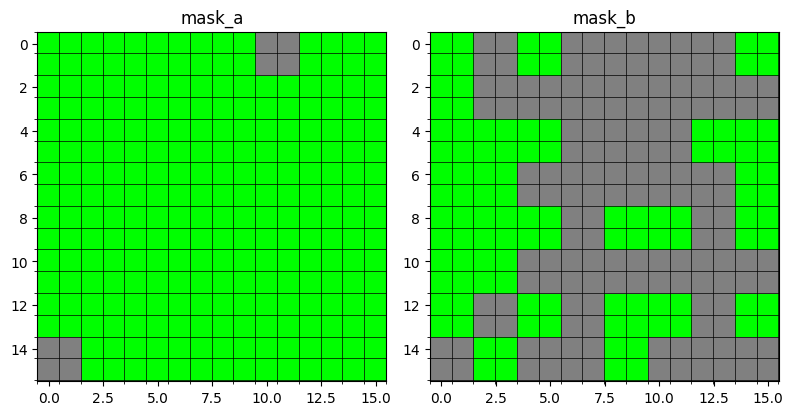

Frobenius norm: 3.734375
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.q_proj with FactorizedLinear (Bottleneck: 4096)
torch.Size([1024, 4096])


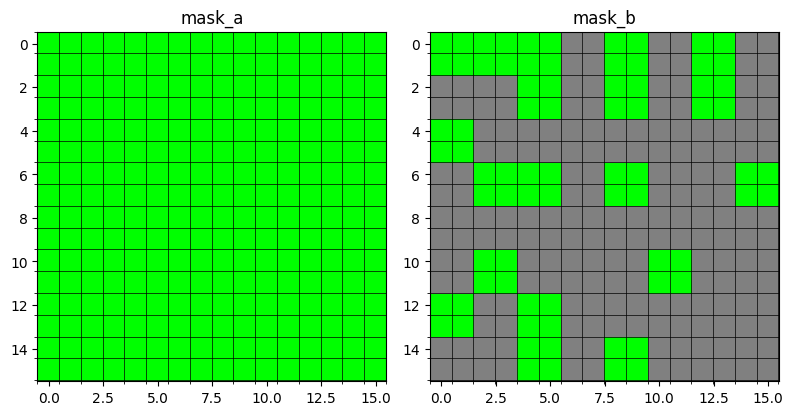

Frobenius norm: 3.3125
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1042430 non-zero entries (99.4%)
B has 1045870 non-zero entries (24.9%)
Replaced model.layers.0.self_attn.k_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([1024, 4096])


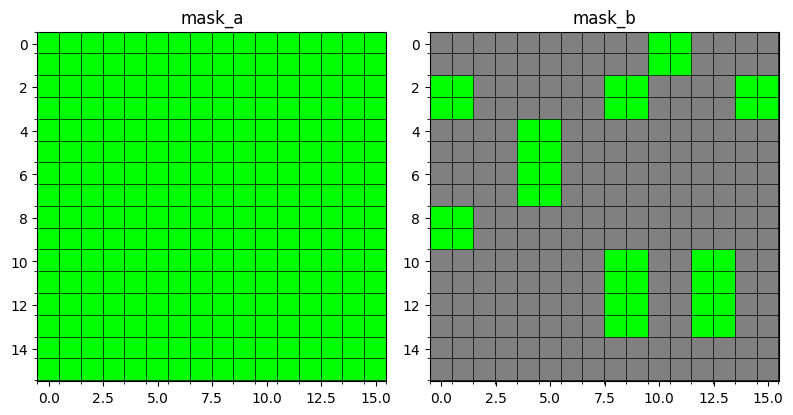

Frobenius norm: 3.71875
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1048572 non-zero entries (100.0%)
B has 1048576 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.v_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([4096, 4096])


KeyboardInterrupt: 

In [909]:
class FactorizedLinear(nn.Sequential):
    '''Helper to wrap L and R into a single unit'''
    def __init__(self, layer_R, layer_L):
        super().__init__(layer_R, layer_L)

@torch.no_grad()
def prune_model(model):
    layers_to_replace = []
    for name, module in model.named_modules():
        if name == 'lm_head':
            continue
        if isinstance(module, nn.Linear):
            layers_to_replace.append((name, module))
    print(len(layers_to_replace))

    for name, layer in layers_to_replace:
        dtype = layer.weight.dtype

        W = layer.weight.data.to(device='cuda')
        print(W.shape)

        XX = torch.eye(W.shape[1], device='cuda')
        prod, A, B = _factorize(W, XX, mask_type='blocks', bsp=0.25, sp=0.5)
        mid_dim = A.shape[1]
        layer_R = nn.Linear(layer.in_features, mid_dim, bias=False, dtype=dtype)
        layer_L = nn.Linear(mid_dim, layer.out_features, bias=layer.bias is not None, dtype=dtype)

        frobenius = torch.norm(prod - W, p='fro')
        print(f'Frobenius norm: {frobenius.item()}')

        A_cpu = A.cpu()
        B_cpu = B.cpu()

        nz_count_A = torch.count_nonzero(A_cpu).item()
        nz_count_B = torch.count_nonzero(B_cpu).item()

        print(f'A.size() = {A_cpu.size()}')
        print(f'B.size() = {B_cpu.size()}')

        n_a = A_cpu.size(dim=0)
        m_a = A_cpu.size(dim=1)
        n_b = B_cpu.size(dim=0)
        m_b = B_cpu.size(dim=1)

        print(f'A has {nz_count_A} non-zero entries ({round(nz_count_A/(n_a*m_a)*100, 1)}%)')
        print(f'B has {nz_count_B} non-zero entries ({round(nz_count_B/(n_b*m_b)*100, 1)}%)')

        layer_R.weight.copy_(B.to(dtype))
        layer_L.weight.copy_(A.to(dtype))
        if layer.bias is not None:
            layer_L.bias.copy_(layer.bias.to(dtype))

        if '.' in name:
            parent_name, attr_name = name.rsplit('.', 1)
            parent = dict(model.named_modules())[parent_name]
        else:
            parent = model
            attr_name = name
            
        setattr(parent, attr_name, FactorizedLinear(layer_R, layer_L))
        print(f'Replaced {name} with FactorizedLinear (Bottleneck: {mid_dim})')
        torch.cuda.empty_cache()

prune_model(model)
test_perplexity_and_response(model, tokenizer)

Cleanup:

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()